# Phase 1: Musicological Analysis of Chopin's Waltz Corpus

**Project:** Completing Chopin's Lost Waltz using AI  
**Goal:** Extract a quantitative "style fingerprint" from the 19 known Chopin waltzes, then compare with the newly discovered waltz fragment.

This notebook covers:
1. Loading and inspecting all 20 MIDI files
2. Extracting structural, melodic, harmonic, rhythmic, and textural features
3. Building visualizations of Chopin's waltz style
4. Comparing the lost waltz to the corpus
5. Exporting the style fingerprint for later evaluation (Phase 5)

## 1.0 — Setup

In [6]:
import pretty_midi
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from pathlib import Path
import json
import os
import warnings
warnings.filterwarnings('ignore')

# ----- CONFIGURE THIS PATH -----
# Point this to wherever your MIDI files are stored
MIDI_DIR = Path("../data/raw")
# --------------------------------

# Plotting style
plt.rcParams.update({
    'figure.facecolor': '#FDFBF7',
    'axes.facecolor': '#FDFBF7',
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 130,
})

# Color palette
GOLD = '#C4973B'
DARK = '#1A1A2E'
BLUE = '#0F3460'
RED  = '#C0392B'

print(f"Looking for MIDI files in: {MIDI_DIR.resolve()}")
midi_files = sorted(MIDI_DIR.glob("*.mid"))
print(f"Found {len(midi_files)} files:")
for f in midi_files:
    print(f"  {f.name} ({f.stat().st_size / 1024:.1f} KB)")

Looking for MIDI files in: /Users/jawadmallat/Desktop/Chopin_Waltz_Completion/data/raw
Found 20 files:
  New_Chopin_Waltz_.mid (3.7 KB)
  Waltz_10_op69no2-in-B-minor.mid (14.8 KB)
  Waltz_11_op70no1-in-Gb-major.mid (10.0 KB)
  Waltz_12_op70no2-in-F-minor.mid (9.8 KB)
  Waltz_13_op70no3-in-Db-major.mid (10.5 KB)
  Waltz_14_B56-in-E-minor.mid (13.1 KB)
  Waltz_15_B44-in-E-major.mid (8.4 KB)
  Waltz_16_B21-in-Ab-major.mid (10.2 KB)
  Waltz_17_B46-in-Eb-major.mid (11.9 KB)
  Waltz_18_B133-in-Eb-major.mid (4.0 KB)
  Waltz_19_B150-in-A-minor.mid (6.8 KB)
  Waltz_1_op18-in-Eb-major.mid (28.0 KB)
  Waltz_2_op34no1-in-Ab-major.mid (26.8 KB)
  Waltz_3_op34no2-in-A-minor.mid (13.2 KB)
  Waltz_4_op34no3-in-F-major.mid (12.8 KB)
  Waltz_5_op42-in-Ab-major.mid (22.1 KB)
  Waltz_6_op64no1-in-Db-major.mid (10.1 KB)
  Waltz_7_op64no2-in-C#-minor.mid (13.1 KB)
  Waltz_8_op64no3-in-Ab-major.mid (15.3 KB)
  Waltz_9_op69no1-in-Ab-major.mid (12.5 KB)


## 1.1 — Load and Parse All MIDI Files

In [7]:
def analyze_midi(filepath):
    """Extract comprehensive features from a single MIDI file."""
    pm = pretty_midi.PrettyMIDI(str(filepath))
    
    # Collect all notes
    all_notes = []
    for inst in pm.instruments:
        all_notes.extend(inst.notes)
    all_notes.sort(key=lambda n: n.start)
    
    if not all_notes:
        return None
    
    pitches = [n.pitch for n in all_notes]
    velocities = [n.velocity for n in all_notes]
    durations = [n.end - n.start for n in all_notes]
    total_duration = pm.get_end_time()
    
    # Tempo
    tempo_changes = pm.get_tempo_changes()
    tempos = tempo_changes[1].tolist() if len(tempo_changes[1]) > 0 else [120]
    avg_tempo = sum(tempos) / len(tempos)
    
    # Extract melody (top voice at each onset)
    onset_groups = defaultdict(list)
    for n in all_notes:
        bucket = round(n.start, 2)
        onset_groups[bucket].append(n)
    
    melody_pitches = []
    for t in sorted(onset_groups.keys()):
        top_note = max(onset_groups[t], key=lambda n: n.pitch)
        melody_pitches.append(top_note.pitch)
    
    # Bass notes (lowest at each onset)
    bass_pitches = []
    for t in sorted(onset_groups.keys()):
        bottom_note = min(onset_groups[t], key=lambda n: n.pitch)
        bass_pitches.append(bottom_note.pitch)
    
    # Melody intervals
    intervals = [melody_pitches[i+1] - melody_pitches[i] 
                 for i in range(len(melody_pitches)-1)]
    
    # Pitch class distribution (C=0, C#=1, ... B=11)
    pitch_classes = [p % 12 for p in pitches]
    
    # Notes per beat estimate
    beats = pm.get_beats()
    
    # Extract key from filename
    fname = filepath.stem
    key_info = "unknown"
    if "-in-" in fname:
        key_info = fname.split("-in-")[1].replace("-", " ").replace("_", "#")
    
    return {
        "filename": filepath.name,
        "key": key_info,
        "num_notes": len(all_notes),
        "total_duration_sec": round(total_duration, 2),
        "total_duration_min": round(total_duration / 60, 2),
        "avg_tempo": round(avg_tempo, 1),
        "pitch_range": [min(pitches), max(pitches)],
        "pitch_mean": round(np.mean(pitches), 1),
        "pitch_std": round(np.std(pitches), 1),
        "velocity_range": [min(velocities), max(velocities)],
        "velocity_mean": round(np.mean(velocities), 1),
        "velocity_std": round(np.std(velocities), 1),
        "avg_note_duration": round(np.mean(durations), 3),
        "notes_per_second": round(len(all_notes) / total_duration, 2),
        "num_beats": len(beats),
        # Raw data for distributions
        "all_pitches": pitches,
        "all_velocities": velocities,
        "all_durations": durations,
        "melody_pitches": melody_pitches,
        "bass_pitches": bass_pitches,
        "melody_intervals": intervals,
        "pitch_classes": pitch_classes,
    }

# Analyze all files
corpus = {}  # The 19 known waltzes
lost = None  # The discovered waltz

for f in midi_files:
    result = analyze_midi(f)
    if result is None:
        print(f"WARNING: {f.name} has no notes!")
        continue
    if "New_Chopin" in f.name:
        lost = result
        print(f"  ★ Lost Waltz loaded: {result['num_notes']} notes, {result['total_duration_sec']}s")
    else:
        corpus[f.name] = result
        print(f"  ✓ {f.name}: {result['num_notes']} notes, {result['total_duration_min']} min, key={result['key']}")

print(f"\nLoaded {len(corpus)} known waltzes + 1 lost waltz")

  ★ Lost Waltz loaded: 536 notes, 54.25s
  ✓ Waltz_10_op69no2-in-B-minor.mid: 1936 notes, 4.07 min, key=B minor
  ✓ Waltz_11_op70no1-in-Gb-major.mid: 1392 notes, 1.75 min, key=Gb major
  ✓ Waltz_12_op70no2-in-F-minor.mid: 1364 notes, 2.6 min, key=F minor
  ✓ Waltz_13_op70no3-in-Db-major.mid: 1577 notes, 3.58 min, key=Db major
  ✓ Waltz_14_B56-in-E-minor.mid: 1695 notes, 2.46 min, key=E minor
  ✓ Waltz_15_B44-in-E-major.mid: 1257 notes, 2.63 min, key=E major
  ✓ Waltz_16_B21-in-Ab-major.mid: 1335 notes, 1.06 min, key=Ab major
  ✓ Waltz_17_B46-in-Eb-major.mid: 1614 notes, 2.6 min, key=Eb major
  ✓ Waltz_18_B133-in-Eb-major.mid: 487 notes, 1.74 min, key=Eb major
  ✓ Waltz_19_B150-in-A-minor.mid: 937 notes, 2.0 min, key=A minor
  ✓ Waltz_1_op18-in-Eb-major.mid: 4418 notes, 5.62 min, key=Eb major
  ✓ Waltz_2_op34no1-in-Ab-major.mid: 4084 notes, 4.77 min, key=Ab major
  ✓ Waltz_3_op34no2-in-A-minor.mid: 1947 notes, 4.94 min, key=A minor
  ✓ Waltz_4_op34no3-in-F-major.mid: 1876 notes, 2.7 min

## 1.2 — Corpus Overview Table

In [8]:
# Print a nice summary table
print(f"{'Waltz':<42} {'Key':<12} {'Notes':>6} {'Dur':>6} {'Tempo':>6} {'PitchRange':>12} {'AvgVel':>7} {'N/sec':>6}")
print("-" * 100)

for name in sorted(corpus.keys()):
    r = corpus[name]
    short = name.replace('.mid', '')
    pr = f"{r['pitch_range'][0]}-{r['pitch_range'][1]}"
    dur = f"{r['total_duration_min']:.1f}m"
    print(f"{short:<42} {r['key']:<12} {r['num_notes']:>6} {dur:>6} {r['avg_tempo']:>6.0f} {pr:>12} {r['velocity_mean']:>7.1f} {r['notes_per_second']:>6.1f}")

print("-" * 100)
r = lost
pr = f"{r['pitch_range'][0]}-{r['pitch_range'][1]}"
print(f"{'★ LOST WALTZ':<42} {'A minor':<12} {r['num_notes']:>6} {r['total_duration_min']:.1f}m {r['avg_tempo']:>6.0f} {pr:>12} {r['velocity_mean']:>7.1f} {r['notes_per_second']:>6.1f}")

Waltz                                      Key           Notes    Dur  Tempo   PitchRange  AvgVel  N/sec
----------------------------------------------------------------------------------------------------
Waltz_10_op69no2-in-B-minor                B minor        1936   4.1m    119        42-90    59.7    7.9
Waltz_11_op70no1-in-Gb-major               Gb major       1392   1.8m    180       30-101    64.0   13.3
Waltz_12_op70no2-in-F-minor                F minor        1364   2.6m    133        34-84    77.6    8.7
Waltz_13_op70no3-in-Db-major               Db major       1577   3.6m     96        32-84    73.1    7.3
Waltz_14_B56-in-E-minor                    E minor        1695   2.5m    224       28-100    66.4   11.5
Waltz_15_B44-in-E-major                    E major        1257   2.6m    106        39-97    66.5    8.0
Waltz_16_B21-in-Ab-major                   Ab major       1335   1.1m    151        39-92    67.4   21.0
Waltz_17_B46-in-Eb-major                   Eb major       1

## 1.3 — Style Fingerprint: 9-Panel Visualization

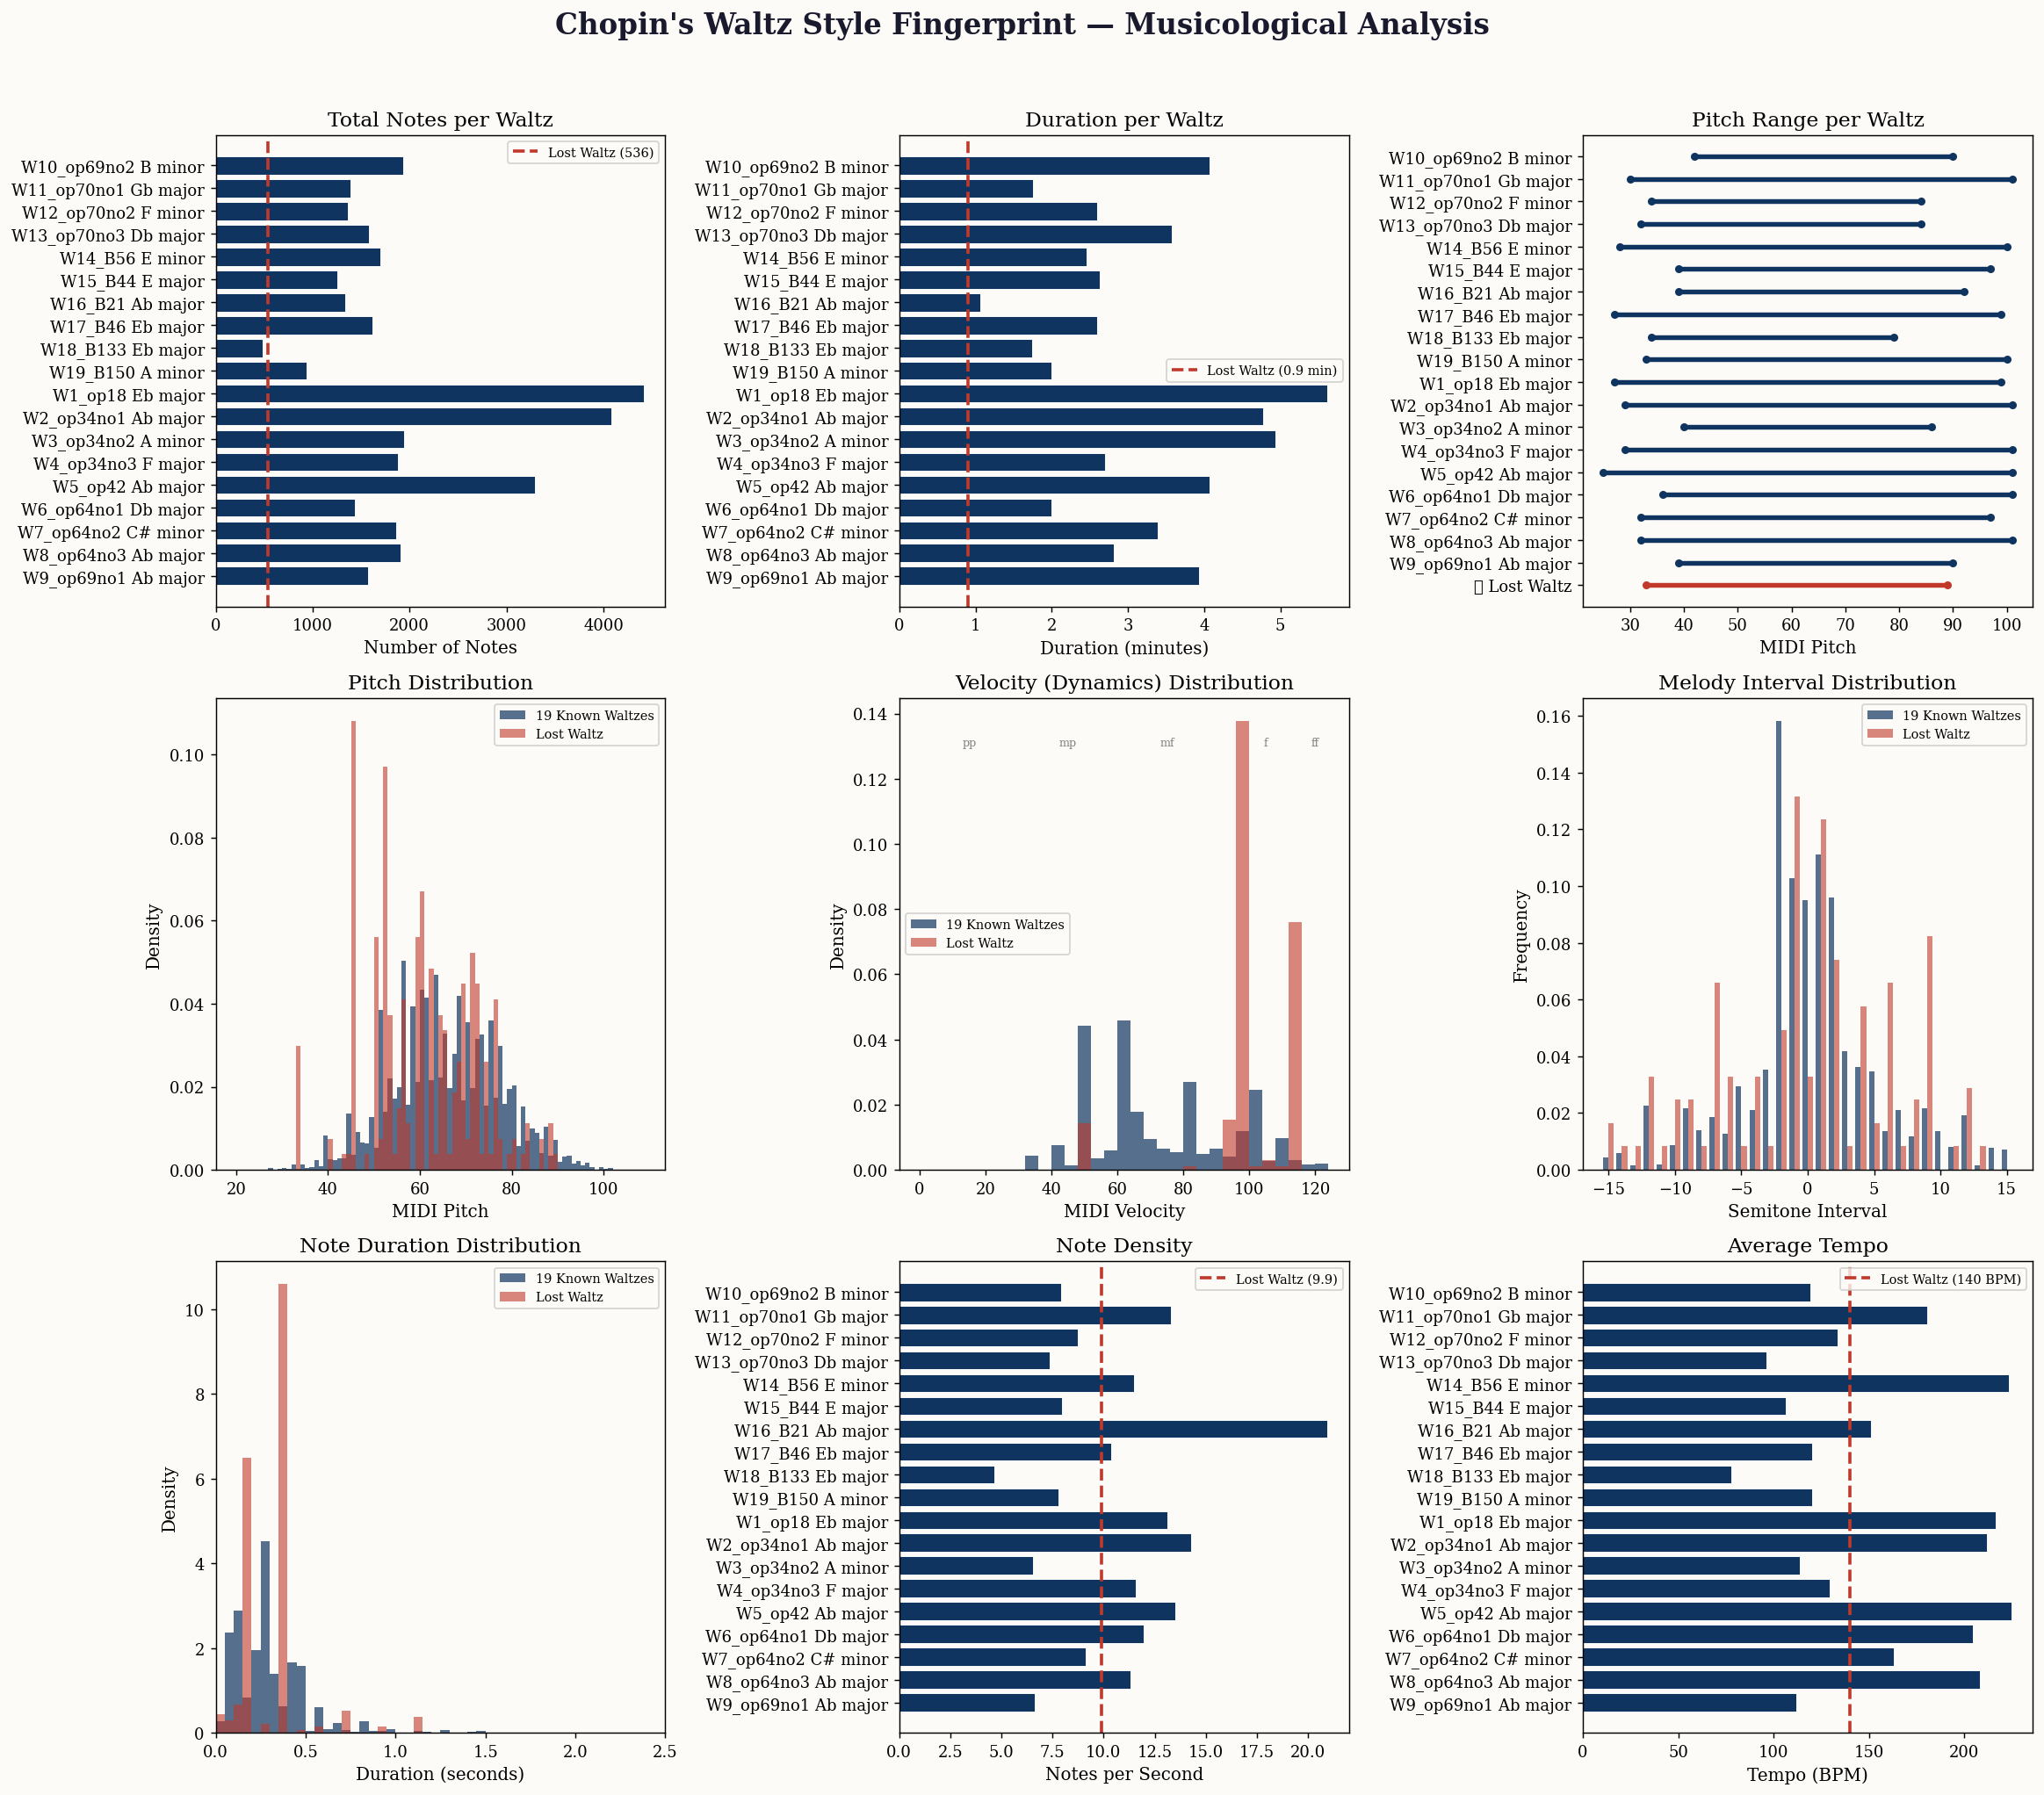

Saved to analysis/style_fingerprint.png


In [9]:
def short_name(fname):
    """Create a compact label for plotting."""
    return fname.replace('.mid', '').replace('Waltz_', 'W').replace('-in-', ' ').replace('-', ' ')

names = [short_name(k) for k in sorted(corpus.keys())]

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle("Chopin's Waltz Style Fingerprint — Musicological Analysis",
             fontsize=18, fontweight='bold', color=DARK, y=0.98)

# --- 1. Note Count ---
ax = axes[0, 0]
note_counts = [corpus[k]['num_notes'] for k in sorted(corpus.keys())]
ax.barh(names, note_counts, color=BLUE, edgecolor='white', linewidth=0.5)
ax.axvline(x=lost['num_notes'], color=RED, linestyle='--', linewidth=2, label=f'Lost Waltz ({lost["num_notes"]})')
ax.set_xlabel('Number of Notes')
ax.set_title('Total Notes per Waltz')
ax.legend(fontsize=8)
ax.invert_yaxis()

# --- 2. Duration ---
ax = axes[0, 1]
durations_min = [corpus[k]['total_duration_min'] for k in sorted(corpus.keys())]
ax.barh(names, durations_min, color=BLUE, edgecolor='white', linewidth=0.5)
ax.axvline(x=lost['total_duration_min'], color=RED, linestyle='--', linewidth=2,
           label=f'Lost Waltz ({lost["total_duration_min"]:.1f} min)')
ax.set_xlabel('Duration (minutes)')
ax.set_title('Duration per Waltz')
ax.legend(fontsize=8)
ax.invert_yaxis()

# --- 3. Pitch Range ---
ax = axes[0, 2]
for i, k in enumerate(sorted(corpus.keys())):
    low, high = corpus[k]['pitch_range']
    ax.plot([low, high], [i, i], color=BLUE, linewidth=3, solid_capstyle='round')
    ax.plot([low, high], [i, i], 'o', color=BLUE, markersize=4)
# Lost waltz
low_l, high_l = lost['pitch_range']
ax.plot([low_l, high_l], [len(corpus), len(corpus)], color=RED, linewidth=3, solid_capstyle='round')
ax.plot([low_l, high_l], [len(corpus), len(corpus)], 'o', color=RED, markersize=4)
ax.set_yticks(range(len(names) + 1))
ax.set_yticklabels(names + ['★ Lost Waltz'])
ax.set_xlabel('MIDI Pitch')
ax.set_title('Pitch Range per Waltz')
ax.invert_yaxis()

# --- 4. Pitch Distribution ---
ax = axes[1, 0]
all_pitches = [p for k in corpus for p in corpus[k]['all_pitches']]
ax.hist(all_pitches, bins=range(20, 110), color=BLUE, alpha=0.7, density=True, label='19 Known Waltzes')
ax.hist(lost['all_pitches'], bins=range(20, 110), color=RED, alpha=0.6, density=True, label='Lost Waltz')
ax.set_xlabel('MIDI Pitch')
ax.set_ylabel('Density')
ax.set_title('Pitch Distribution')
ax.legend(fontsize=8)

# --- 5. Velocity Distribution ---
ax = axes[1, 1]
all_vel = [v for k in corpus for v in corpus[k]['all_velocities']]
ax.hist(all_vel, bins=range(0, 128, 4), color=BLUE, alpha=0.7, density=True, label='19 Known Waltzes')
ax.hist(lost['all_velocities'], bins=range(0, 128, 4), color=RED, alpha=0.6, density=True, label='Lost Waltz')
ax.set_xlabel('MIDI Velocity')
ax.set_ylabel('Density')
ax.set_title('Velocity (Dynamics) Distribution')
ax.legend(fontsize=8)
for x, label in [(15, 'pp'), (45, 'mp'), (75, 'mf'), (105, 'f'), (120, 'ff')]:
    ax.text(x, ax.get_ylim()[1]*0.9, label, fontsize=7, ha='center', color='gray')

# --- 6. Melody Interval Distribution ---
ax = axes[1, 2]
all_intervals = [i for k in corpus for i in corpus[k]['melody_intervals']]
interval_range = range(-15, 16)
known_counts = Counter(i for i in all_intervals if -15 <= i <= 15)
lost_counts = Counter(i for i in lost['melody_intervals'] if -15 <= i <= 15)
known_total = sum(known_counts.values())
lost_total = sum(lost_counts.values())
known_freq = [known_counts.get(i, 0) / known_total for i in interval_range]
lost_freq = [lost_counts.get(i, 0) / lost_total for i in interval_range]
w = 0.4
ax.bar([x - w/2 for x in interval_range], known_freq, width=w, color=BLUE, alpha=0.7, label='19 Known Waltzes')
ax.bar([x + w/2 for x in interval_range], lost_freq, width=w, color=RED, alpha=0.6, label='Lost Waltz')
ax.set_xlabel('Semitone Interval')
ax.set_ylabel('Frequency')
ax.set_title('Melody Interval Distribution')
ax.legend(fontsize=8)

# --- 7. Note Duration Distribution ---
ax = axes[2, 0]
all_dur = [d for k in corpus for d in corpus[k]['all_durations']]
ax.hist(all_dur, bins=np.arange(0, 3, 0.05), color=BLUE, alpha=0.7, density=True, label='19 Known Waltzes')
ax.hist(lost['all_durations'], bins=np.arange(0, 3, 0.05), color=RED, alpha=0.6, density=True, label='Lost Waltz')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Density')
ax.set_title('Note Duration Distribution')
ax.set_xlim(0, 2.5)
ax.legend(fontsize=8)

# --- 8. Note Density ---
ax = axes[2, 1]
nps = [corpus[k]['notes_per_second'] for k in sorted(corpus.keys())]
ax.barh(names, nps, color=BLUE, edgecolor='white', linewidth=0.5)
ax.axvline(x=lost['notes_per_second'], color=RED, linestyle='--', linewidth=2,
           label=f'Lost Waltz ({lost["notes_per_second"]:.1f})')
ax.set_xlabel('Notes per Second')
ax.set_title('Note Density')
ax.legend(fontsize=8)
ax.invert_yaxis()

# --- 9. Tempo ---
ax = axes[2, 2]
tempos = [corpus[k]['avg_tempo'] for k in sorted(corpus.keys())]
ax.barh(names, tempos, color=BLUE, edgecolor='white', linewidth=0.5)
ax.axvline(x=lost['avg_tempo'], color=RED, linestyle='--', linewidth=2,
           label=f'Lost Waltz ({lost["avg_tempo"]:.0f} BPM)')
ax.set_xlabel('Tempo (BPM)')
ax.set_title('Average Tempo')
ax.legend(fontsize=8)
ax.invert_yaxis()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../analysis/style_fingerprint.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to analysis/style_fingerprint.png')

## 1.4 — Piano Roll of the Lost Waltz

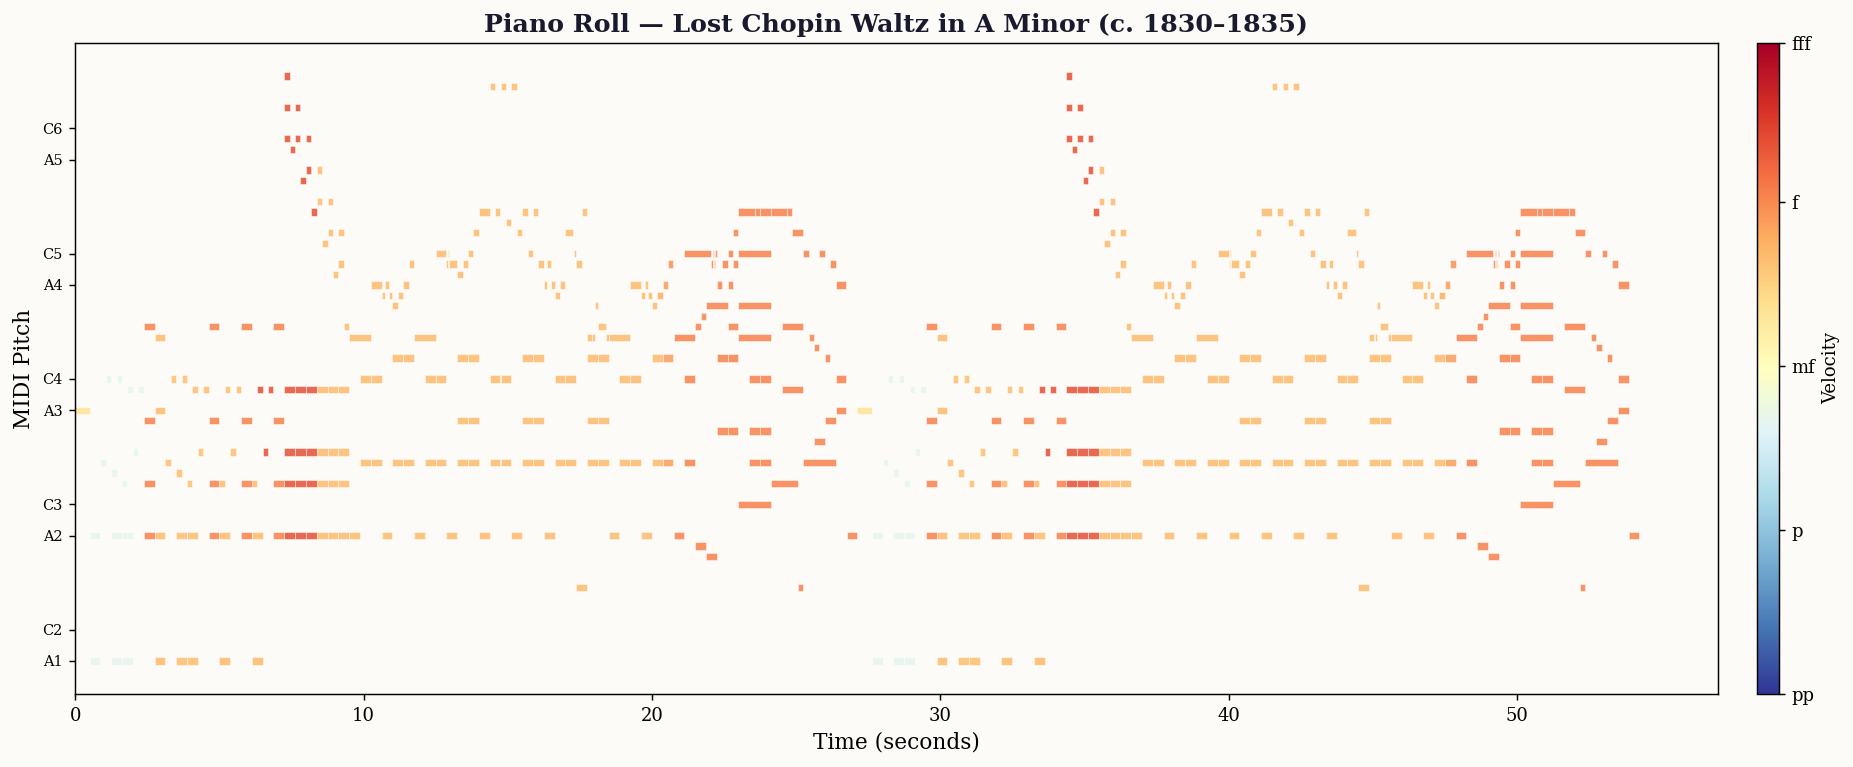

Saved to analysis/lost_waltz_piano_roll.png


In [10]:
# Load the lost waltz directly for piano roll
lost_path = MIDI_DIR / "New_Chopin_Waltz_.mid"
pm = pretty_midi.PrettyMIDI(str(lost_path))
all_notes = []
for inst in pm.instruments:
    all_notes.extend(inst.notes)

fig, ax = plt.subplots(figsize=(16, 6))

for note in all_notes:
    color_val = note.velocity / 127.0
    color = plt.cm.RdYlBu_r(color_val * 0.7 + 0.15)
    ax.barh(note.pitch, note.end - note.start, left=note.start,
            height=0.7, color=color, edgecolor='white', linewidth=0.3, alpha=0.85)

ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('MIDI Pitch', fontsize=12)
ax.set_title('Piano Roll — Lost Chopin Waltz in A Minor (c. 1830–1835)',
             fontsize=14, fontweight='bold', color=DARK)

# Pitch labels
pitch_labels = {33: 'A1', 36: 'C2', 45: 'A2', 48: 'C3', 57: 'A3',
                60: 'C4', 69: 'A4', 72: 'C5', 81: 'A5', 84: 'C6'}
ax.set_yticks([n for n in pitch_labels if 30 <= n <= 92])
ax.set_yticklabels([pitch_labels[n] for n in pitch_labels if 30 <= n <= 92], fontsize=8)

# Velocity colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlBu_r, norm=plt.Normalize(0, 127))
cbar = plt.colorbar(sm, ax=ax, pad=0.02, aspect=30)
cbar.set_label('Velocity', fontsize=10)
cbar.set_ticks([0, 32, 64, 96, 127])
cbar.set_ticklabels(['pp', 'p', 'mf', 'f', 'fff'])

plt.tight_layout()
plt.savefig('../analysis/lost_waltz_piano_roll.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to analysis/lost_waltz_piano_roll.png')

## 1.5 — Key Distribution Analysis

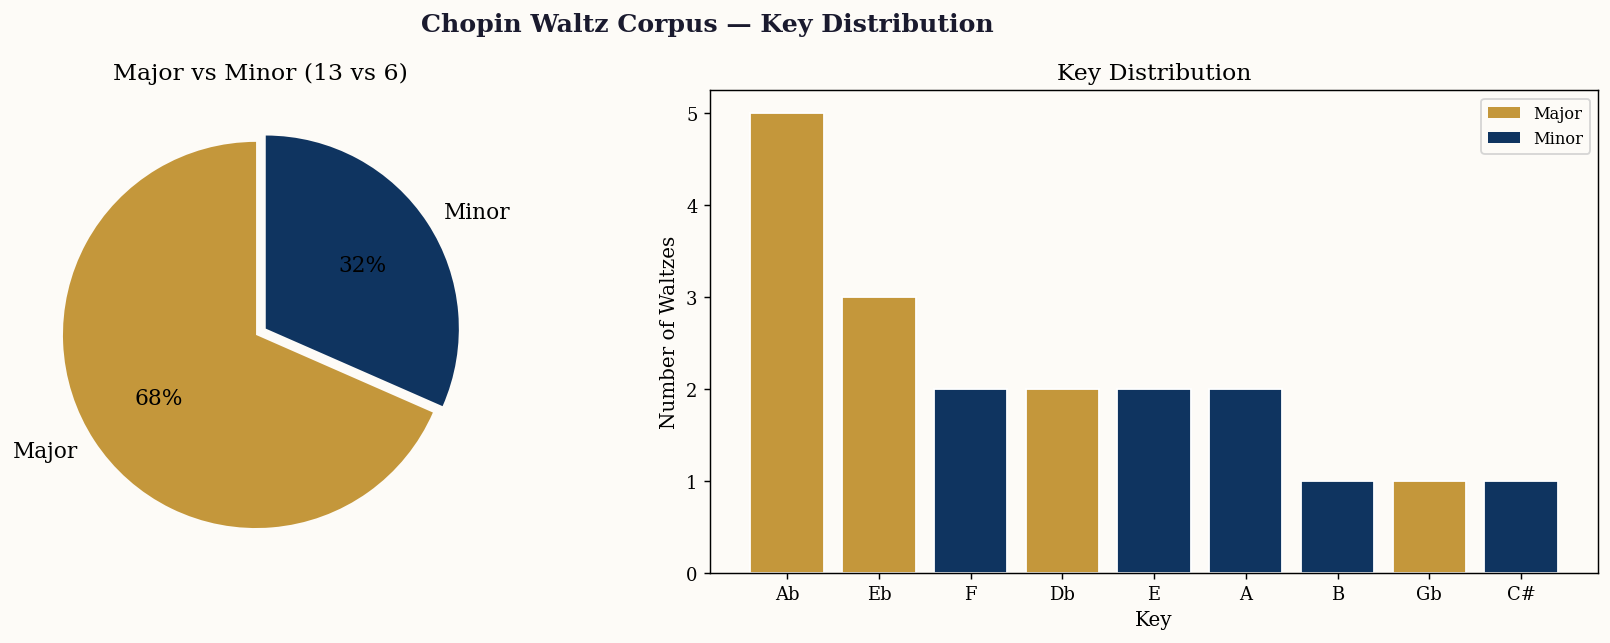


Major keys (13): Gb, Db, E, Ab, Eb, Eb, Eb, Ab, F, Ab, Db, Ab, Ab
Minor keys (6): B, F, E, A, A, C#

The lost waltz is in A minor — same key as Waltz 3 (Op.34/2) and Waltz 19 (B.150)


In [11]:
# Extract keys from filenames
major_keys = []
minor_keys = []
all_keys = []

for name, data in corpus.items():
    key = data['key']
    if 'major' in key:
        k = key.replace(' major', '')
        major_keys.append(k)
        all_keys.append((k, 'Major'))
    elif 'minor' in key:
        k = key.replace(' minor', '')
        minor_keys.append(k)
        all_keys.append((k, 'Minor'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chopin Waltz Corpus — Key Distribution",
             fontsize=14, fontweight='bold', color=DARK)

# Pie chart: Major vs Minor
ax = axes[0]
sizes = [len(major_keys), len(minor_keys)]
ax.pie(sizes, labels=['Major', 'Minor'], colors=[GOLD, BLUE],
       autopct='%1.0f%%', startangle=90, explode=(0.03, 0.03),
       textprops={'fontsize': 12})
ax.set_title(f'Major vs Minor ({len(major_keys)} vs {len(minor_keys)})')

# Bar chart: individual keys
ax = axes[1]
key_counts = Counter([k for k, _ in all_keys])
keys_sorted = sorted(key_counts.keys(), key=lambda x: key_counts[x], reverse=True)
counts_sorted = [key_counts[k] for k in keys_sorted]
mode_colors = []
for k in keys_sorted:
    mode = [m for key, m in all_keys if key == k][0]
    mode_colors.append(GOLD if mode == 'Major' else BLUE)

ax.bar(keys_sorted, counts_sorted, color=mode_colors, edgecolor='white')
ax.set_xlabel('Key')
ax.set_ylabel('Number of Waltzes')
ax.set_title('Key Distribution')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=GOLD, label='Major'),
                   Patch(facecolor=BLUE, label='Minor')], fontsize=9)

plt.tight_layout()
plt.savefig('../analysis/key_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMajor keys ({len(major_keys)}): {', '.join(major_keys)}")
print(f"Minor keys ({len(minor_keys)}): {', '.join(minor_keys)}")
print(f"\nThe lost waltz is in A minor — same key as Waltz 3 (Op.34/2) and Waltz 19 (B.150)")

## 1.6 — Pitch Class Distribution (Chromatic Profile)

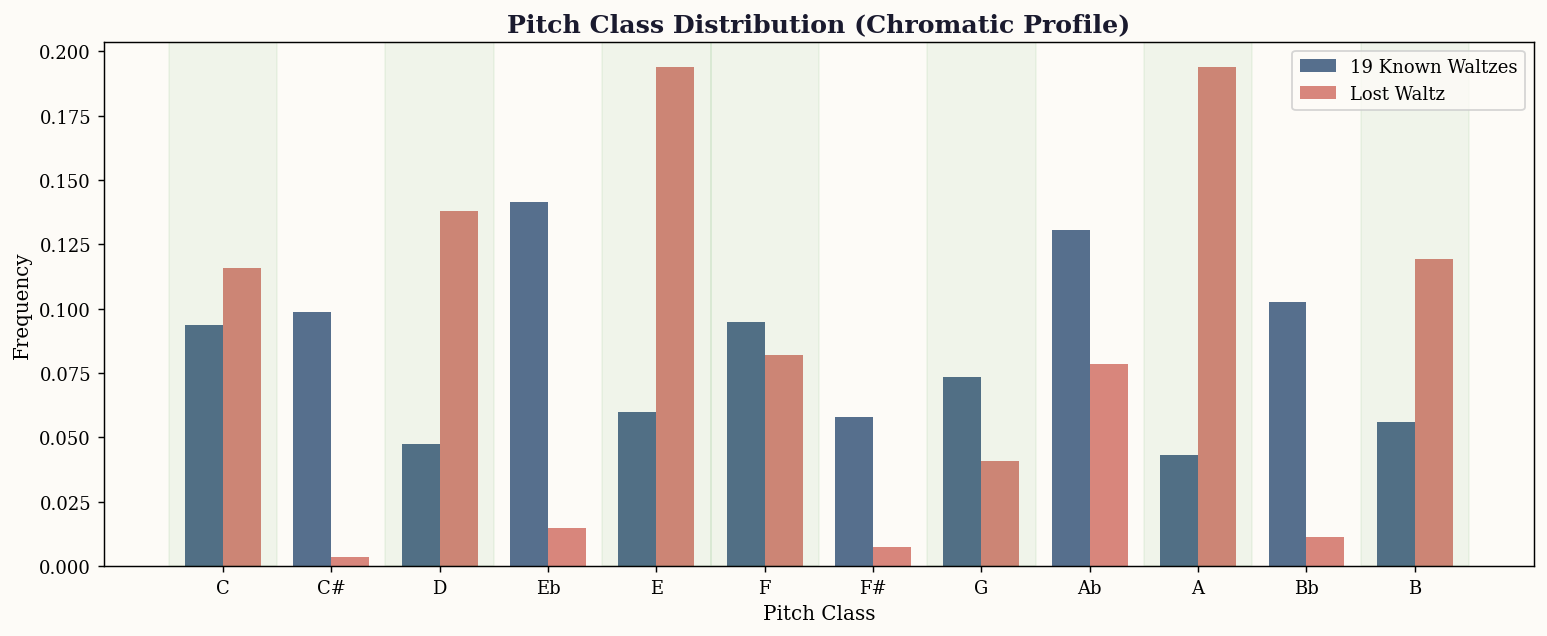

Green shading = A natural minor scale tones


In [12]:
# Which pitch classes (C, C#, D, ...) does Chopin favor in waltzes?
note_names = ['C', 'C#', 'D', 'Eb', 'E', 'F', 'F#', 'G', 'Ab', 'A', 'Bb', 'B']

# Corpus pitch class distribution
all_pc = [p % 12 for k in corpus for p in corpus[k]['all_pitches']]
lost_pc = [p % 12 for p in lost['all_pitches']]

corpus_pc_counts = Counter(all_pc)
lost_pc_counts = Counter(lost_pc)
corpus_total = sum(corpus_pc_counts.values())
lost_total = sum(lost_pc_counts.values())

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(12)
w = 0.35
corpus_freq = [corpus_pc_counts.get(i, 0) / corpus_total for i in range(12)]
lost_freq = [lost_pc_counts.get(i, 0) / lost_total for i in range(12)]

ax.bar(x - w/2, corpus_freq, width=w, color=BLUE, alpha=0.7, label='19 Known Waltzes')
ax.bar(x + w/2, lost_freq, width=w, color=RED, alpha=0.6, label='Lost Waltz')

ax.set_xticks(x)
ax.set_xticklabels(note_names)
ax.set_xlabel('Pitch Class')
ax.set_ylabel('Frequency')
ax.set_title('Pitch Class Distribution (Chromatic Profile)', fontsize=14, fontweight='bold', color=DARK)
ax.legend()

# Highlight A minor scale tones (A, B, C, D, E, F, G)
a_minor_pcs = [9, 11, 0, 2, 4, 5, 7]  # A, B, C, D, E, F, G
for pc in a_minor_pcs:
    ax.axvspan(pc - 0.5, pc + 0.5, alpha=0.05, color='green')

plt.tight_layout()
plt.savefig('../analysis/pitch_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Green shading = A natural minor scale tones')

## 1.7 — Summary Statistics & Lost Waltz Comparison

In [13]:
# Compute corpus statistics
note_counts_arr = np.array([corpus[k]['num_notes'] for k in corpus])
dur_arr = np.array([corpus[k]['total_duration_sec'] for k in corpus])
nps_arr = np.array([corpus[k]['notes_per_second'] for k in corpus])
vel_arr = np.array([v for k in corpus for v in corpus[k]['all_velocities']])
pitch_arr = np.array([p for k in corpus for p in corpus[k]['all_pitches']])
all_intervals = [i for k in corpus for i in corpus[k]['melody_intervals']]

interval_names = {0: 'Unison', 1: 'm2↑', 2: 'M2↑', 3: 'm3↑', 4: 'M3↑', 5: 'P4↑',
                  7: 'P5↑', 12: 'Oct↑', -1: 'm2↓', -2: 'M2↓', -3: 'm3↓', -4: 'M3↓',
                  -5: 'P4↓', -7: 'P5↓', -12: 'Oct↓'}

print('=' * 60)
print('CHOPIN WALTZ CORPUS — STYLE FINGERPRINT SUMMARY')
print('=' * 60)

print(f'\nCorpus size: {len(corpus)} waltzes')
print(f'Key distribution: {len(major_keys)} major, {len(minor_keys)} minor')

print(f'\n--- Scale ---')
print(f'Note count:   mean={note_counts_arr.mean():.0f}, range=[{note_counts_arr.min()}, {note_counts_arr.max()}]')
print(f'Duration:     mean={dur_arr.mean()/60:.1f} min, range=[{dur_arr.min()/60:.1f}, {dur_arr.max()/60:.1f}] min')

print(f'\n--- Pitch ---')
print(f'Full range:   MIDI {pitch_arr.min()} to {pitch_arr.max()}')
print(f'Mean pitch:   {pitch_arr.mean():.1f} (std={pitch_arr.std():.1f})')

print(f'\n--- Dynamics ---')
print(f'Velocity:     mean={vel_arr.mean():.1f}, std={vel_arr.std():.1f}')
print(f'Range:        {vel_arr.min()} to {vel_arr.max()}')

print(f'\n--- Density ---')
print(f'Notes/second: mean={nps_arr.mean():.1f}, range=[{nps_arr.min():.1f}, {nps_arr.max():.1f}]')

print(f'\n--- Top 10 Melody Intervals ---')
interval_counter = Counter(all_intervals)
for interval, count in interval_counter.most_common(10):
    pct = count / len(all_intervals) * 100
    name = interval_names.get(interval, f'{interval:+d}')
    print(f'  {interval:+3d} ({name:>6}): {pct:.1f}%')

print(f'\n{"=" * 60}')
print(f'LOST WALTZ vs CORPUS')
print(f'{"=" * 60}')
print(f'Notes:        {lost["num_notes"]} (corpus mean: {note_counts_arr.mean():.0f}) — {lost["num_notes"]/note_counts_arr.mean()*100:.0f}% of average')
print(f'Duration:     {lost["total_duration_sec"]:.1f}s = {lost["total_duration_min"]:.1f}min (corpus mean: {dur_arr.mean()/60:.1f}min) — {lost["total_duration_sec"]/dur_arr.mean()*100:.0f}% of average')
print(f'Velocity:     {lost["velocity_mean"]:.1f} (corpus: {vel_arr.mean():.1f}) — LOUDER than average')
print(f'Pitch range:  {lost["pitch_range"]} (corpus: {pitch_arr.min()}-{pitch_arr.max()}) — NARROWER range')
print(f'Note density: {lost["notes_per_second"]:.1f} n/s (corpus: {nps_arr.mean():.1f} n/s) — similar density')
print(f'\nKey: A minor — shared with Op.34/2 and B.150')
print(f'\nThe lost waltz is roughly {lost["total_duration_sec"]/dur_arr.mean()*100:.0f}% the length of a typical Chopin waltz.')
print(f'To reach average length, the AI would need to generate ~{dur_arr.mean() - lost["total_duration_sec"]:.0f} more seconds of music.')

CHOPIN WALTZ CORPUS — STYLE FINGERPRINT SUMMARY

Corpus size: 19 waltzes
Key distribution: 13 major, 6 minor

--- Scale ---
Note count:   mean=1894, range=[487, 4418]
Duration:     mean=3.1 min, range=[1.1, 5.6] min

--- Pitch ---
Full range:   MIDI 25 to 101
Mean pitch:   65.1 (std=11.7)

--- Dynamics ---
Velocity:     mean=72.2, std=21.6
Range:        1 to 127

--- Density ---
Notes/second: mean=10.5, range=[4.7, 21.0]

--- Top 10 Melody Intervals ---
   -2 (   M2↓): 14.7%
   +1 (   m2↑): 10.3%
   -1 (   m2↓): 9.5%
   +2 (   M2↑): 8.9%
   +0 (Unison): 8.8%
   +3 (   m3↑): 3.9%
   +4 (   M3↑): 3.3%
   -3 (   m3↓): 3.3%
   +5 (   P4↑): 3.2%
   -5 (   P4↓): 2.7%

LOST WALTZ vs CORPUS
Notes:        536 (corpus mean: 1894) — 28% of average
Duration:     54.2s = 0.9min (corpus mean: 3.1min) — 29% of average
Velocity:     100.8 (corpus: 72.2) — LOUDER than average
Pitch range:  [33, 89] (corpus: 25-101) — NARROWER range
Note density: 9.9 n/s (corpus: 10.5 n/s) — similar density

Key: A mino

## 1.8 — Export Style Fingerprint for Phase 5 Evaluation

In [14]:
# Save summary statistics as JSON for later use in evaluation
fingerprint = {
    "corpus_size": len(corpus),
    "note_count": {"mean": float(note_counts_arr.mean()), "std": float(note_counts_arr.std()),
                   "min": int(note_counts_arr.min()), "max": int(note_counts_arr.max())},
    "duration_sec": {"mean": float(dur_arr.mean()), "std": float(dur_arr.std()),
                     "min": float(dur_arr.min()), "max": float(dur_arr.max())},
    "pitch": {"mean": float(pitch_arr.mean()), "std": float(pitch_arr.std()),
              "min": int(pitch_arr.min()), "max": int(pitch_arr.max())},
    "velocity": {"mean": float(vel_arr.mean()), "std": float(vel_arr.std())},
    "notes_per_second": {"mean": float(nps_arr.mean()), "std": float(nps_arr.std())},
    "top_intervals": [
        {"semitones": int(interval), "frequency": round(count / len(all_intervals), 4)}
        for interval, count in interval_counter.most_common(15)
    ],
    "key_distribution": {"major": len(major_keys), "minor": len(minor_keys)},
    "lost_waltz": {
        "num_notes": lost["num_notes"],
        "duration_sec": lost["total_duration_sec"],
        "velocity_mean": lost["velocity_mean"],
        "pitch_range": lost["pitch_range"],
        "notes_per_second": lost["notes_per_second"],
    }
}

output_path = Path('../analysis/style_fingerprint.json')
with open(output_path, 'w') as f:
    json.dump(fingerprint, f, indent=2)

print(f'Style fingerprint saved to {output_path}')
print(f'This will be used in Phase 5 to evaluate AI-generated output.')

Style fingerprint saved to ../analysis/style_fingerprint.json
This will be used in Phase 5 to evaluate AI-generated output.


---
## Summary & Next Steps


1. The average Chopin waltz is ~3.1 minutes long with ~1,894 notes. The lost waltz at ~0.9 minutes is roughly 29% of a typical waltz, supporting Szklener's view that it may be a sketch.

2. The corpus strongly favors flat keys (Ab, Eb, Db) — 68% are in major keys.

3. Chopin's melody writing heavily favors stepwise motion: the top intervals are descending M2 (14.7%), ascending m2 (10.3%), and descending m2 (9.5%).

4. The lost waltz has notably higher velocity (100.8 vs corpus mean 72.2), consistent with experts' description of its "stormy" character and the rare *fortississimo* marking.

5. Despite being short, the lost waltz's note density (9.9 n/s) is very close to the corpus mean (10.5 n/s), suggesting it is written in a typical Chopin waltz texture.

**Next:** Phase 2 — Tokenize the corpus with MidiTok for transformer training.